In [1]:
from paths import HOME_DIR  # Zenodo release shim
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.font_manager as font_manager
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import numpy as np
from tqdm import tqdm
import torch
import os
import sys
import pickle as pkl
import json

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
sys.path.append(os.path.join(os.path.expanduser("~"), "atomic-leaps-dev"))

# optional: clearer CUDA errors
# os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ============================================================================
# Styling Constants
# ============================================================================
DEFAULT_DPI = 300
FIG_WIDTH = 3.25/2  # Width for single panel figures
FIG_HEIGHT = FIG_WIDTH  # Height for single panel figures
MARKERSIZE = 10
scatter_marker_size = MARKERSIZE
fontsize = 8

# Plot styling constants
GRID_ALPHA = 0.3
HIST_ALPHA = 0.3
KDE_LINEWIDTH = 1.25
LEGEND_FRAME_EDGECOLOR = "none"  # Transparent edge
LEGEND_FRAME_BOXSTYLE = "Square"
LEGEND_FRAME_PAD = 0

# Model configuration
MODEL_SIZE = "16x16"
NUM_SITES = 256
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

# HOME_DIR provided by paths shim (Zenodo release)


In [3]:
all_temps = np.array([1.667, 2.269, 3.5714])
all_chem_pots = np.array([0.00])

# output_folder = Path("outputs/ising/1111_10x10")
# output_folder.mkdir(parents=True, exist_ok=True)

Load previously saved results from scripts and plot

In [4]:
# MDNS no annealing (now default)
mdns_outputs = [
    HOME_DIR /
    f"slurm_files/mdns_ising_{MODEL_SIZE}_low_no_anneal/eval/mdns_results.pkl",
    HOME_DIR /
    f"slurm_files/mdns_ising_{MODEL_SIZE}_crit_no_anneal/eval/mdns_results.pkl",
    HOME_DIR /
    f"slurm_files/mdns_ising_{MODEL_SIZE}_high/eval/mdns_results.pkl",
]
mdns_configs = {}
mdns_energies = {}
mdns_x_up = {}
mdns_log_rw = {}
mdns_ness = {}
mdns_free_energies = {}
for mdns_output in mdns_outputs:
    with open(mdns_output, "rb") as f:
        results_dict = pkl.load(f)  # results_dict is a dict of dicts
        mdns_configs.update(results_dict["configs"])
        mdns_energies.update(results_dict["energies"])
        mdns_x_up.update(results_dict["x_up"])
        # mdns_log_rw.update(results_dict["log_rnd"])
        mdns_log_rw.update(results_dict["log_rw"])
        mdns_ness.update(results_dict["ness"])
        mdns_free_energies.update(results_dict["free_energies"])

# MetaDNS WDCE
metadns_outputs = [
    HOME_DIR /
    f"slurm_files/2026_0115_16x16_mdns_ising_16x16_low_temp_metadynamics_wdce_resample_10_num_repl_16_sigma_0.05_height_0.1667_factor_10_batch_size_128_embedding_size_64_blocks_4_buffer_size_1024_n_bins_8_strategy_balanced/eval/mdns_results.pkl",
    # another low temp
    # slurm_files/2026_0115_16x16_mdns_ising_16x16_low_temp_metadynamics_129_bins_wdce_resample_10_num_repl_16_sigma_0.05_height_0.8335_factor_10_batch_size_128_embedding_size_64_blocks_4_buffer_size_1024_n_bins_8_strategy_balanced/eval/mdns_results.pkl
    HOME_DIR /
    f"slurm_files/2026_0112_16x16_mdns_ising_16x16_crit_temp_metadynamics_wdce_resample_10_num_repl_16_sigma_0.05_height_1.1345_factor_10_batch_size_128_embedding_size_64_blocks_4_buffer_size_1024/eval/mdns_results.pkl",
    HOME_DIR /
    f"slurm_files/2026_0115_16x16_mdns_ising_16x16_high_temp_metadynamics_wdce_resample_10_num_repl_16_sigma_0.05_height_1.7855_factor_10_batch_size_128_embedding_size_64_blocks_4_buffer_size_1024_n_bins_8_strategy_balanced/eval/mdns_results.pkl"
]
metadns_configs = {}
metadns_energies = {}
metadns_x_up = {}
metadns_log_rw = {}
metadns_ness = {}
metadns_free_energies = {}
metadns_weights = {}
for metadns_output in metadns_outputs:
    with open(metadns_output, "rb") as f:
        results_dict = pkl.load(f)  # results_dict is a dict of dicts
        metadns_configs.update(results_dict["configs"])
        metadns_energies.update(results_dict["energies"])
        metadns_x_up.update(results_dict["x_up"])
        # metadns_log_rw.update(results_dict["log_rnd"])
        metadns_log_rw.update(results_dict["log_rw"])
        metadns_ness.update(results_dict["ness"])
        metadns_free_energies.update(results_dict["free_energies"])
        metadns_weights.update(results_dict["weights"])

# SGC MCMC Load previously saved results from block sampler
mcmc_output_dir = HOME_DIR / f"benchmarks/outputs/ising/{MODEL_SIZE}_mcmc"
metadata_path = mcmc_output_dir / "metadata.json"
with metadata_path.open("r", encoding="utf-8") as f:
    mcmc_metadata = json.load(f)

mcmc_configs_blocks = defaultdict(list)
mcmc_energies_blocks = defaultdict(list)
mcmc_x_up_blocks = defaultdict(list)

for block_entry in mcmc_metadata["blocks"]:
    block_path = (metadata_path.parent / Path(block_entry["path"]).name)
    with block_path.open("rb") as f:
        block_data = pkl.load(f)
    for key, arr in block_data["configs"].items():
        mcmc_configs_blocks[key].append(arr)
    for key, arr in block_data["energies"].items():
        mcmc_energies_blocks[key].append(arr)
    for key, arr in block_data["x_up"].items():
        mcmc_x_up_blocks[key].append(arr)

mcmc_configs = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in mcmc_configs_blocks.items()
}
mcmc_energies = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in mcmc_energies_blocks.items()
}
mcmc_x_up = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in mcmc_x_up_blocks.items()
}

# SW load previously saved results from block sampler
sw_output_dir = HOME_DIR / \
    f"benchmarks/outputs/ising/{MODEL_SIZE}_sw_1k_samples"
metadata_path = sw_output_dir / "metadata.json"
with metadata_path.open("r", encoding="utf-8") as f:
    sw_metadata = json.load(f)

sw_configs_blocks = defaultdict(list)
sw_energies_blocks = defaultdict(list)
sw_x_up_blocks = defaultdict(list)

for block_entry in sw_metadata["blocks"]:
    block_path = (metadata_path.parent / Path(block_entry["path"]).name)
    with block_path.open("rb") as f:
        block_data = pkl.load(f)
    for key, arr in block_data["configs"].items():
        sw_configs_blocks[key].append(arr)
    for key, arr in block_data["energies"].items():
        sw_energies_blocks[key].append(arr)
    for key, arr in block_data["x_up"].items():
        sw_x_up_blocks[key].append(arr)

sw_configs = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in sw_configs_blocks.items()
}
sw_energies = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in sw_energies_blocks.items()
}
sw_x_up = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in sw_x_up_blocks.items()
}

In [5]:
# Load MetaDNS data (combining low/crit/high temperature files)
metadns_key_mapping = {
    "1.6667K_h0.0000": "1.6670K_h0.0000",
    "2.2691K_h0.0000": "2.2690K_h0.0000",
    "3.5714K_h0.0000": "3.5714K_h0.0000",
}

# Simplified: update all relevant metaDNS dictionaries in one loop
meta_keys_to_update = [(k, metadns_key_mapping[k])
                       for k in metadns_key_mapping if k in metadns_configs]
for old_key, new_key in meta_keys_to_update:
    for dct in [
        metadns_configs,
        metadns_energies,
        metadns_x_up,
        metadns_log_rw,
        metadns_ness,
        metadns_free_energies,
        metadns_weights
    ]:
        if old_key in dct:
            dct[new_key] = dct[old_key]
            # del dct[old_key]

In [6]:
print("MetaDNS WDCE configs:", list(metadns_configs.keys()))

MetaDNS WDCE configs: ['1.6667K_h0.0000', '2.2691K_h0.0000', '3.5714K_h0.0000', '1.6670K_h0.0000', '2.2690K_h0.0000']


In [7]:
print("MetaDNS WDCE energies:", list(metadns_energies.keys()))

MetaDNS WDCE energies: ['1.6667K_h0.0000', '2.2691K_h0.0000', '3.5714K_h0.0000', '1.6670K_h0.0000', '2.2690K_h0.0000']


In [8]:
mcmc_energies.keys()

dict_keys(['1.7K_mu0.00', '2.3K_mu0.00', '3.6K_mu0.00'])

In [9]:
# ============================================================================
# Plot Styling: Markers and Colors
# ============================================================================

# Marker scheme: Method-based (same shape for same method across architectures)
# - train methods: square (s)
# - Paint methods: triangle down (v) - same for all architectures
# - Reference methods: circles (o) and squares (s)
marker_dict = {
    "MDNS": "s",
    "MDNS no anneal": "s",
    "MetaDNS": "s",

    # ARM
    "ARM": "s",

    # Reference methods
    "Wang-Landau": "s",
    "SW": "s",
    "MCMC": "o",
    "ARM-MCMC": "o",
    "Exact": "s",
}

# Color scheme: User-specified colors based on custom matplotlib color cycle
color_dict = {
    "MDNS": "C1",  # Light blue
    # "MDNS no anneal": "C0",  # Dark blue
    "MetaDNS": "C0",   # Dark blue for MAM GNN
    # "MetaDNS WDCE": "C3",   # Yellow
    # "MetaDNS RERF": "C4",   # Red

    # ARM
    "ARM": "C2",  # Green

    # Reference methods
    "Wang-Landau": "C5",  # Dark gray (#495567)
    "MCMC": "C5",  # Gray
    "Exact": "C5",  # Dark gray
    "SW": "C3",  # Red
}

In [10]:
# ============================================================================
# Plot Styling Helper Functions
# ============================================================================
from matplotlib.colors import to_rgba


def resolve_color(name: str, default: str = "C0") -> str:
    """Return the best matching palette color for a label.

    Parameters
    ----------
    name : str
        Method/model name to match against color_dict keys.
    default : str, optional
        Default color to return if no match is found.

    Returns
    -------
    str
        Color specification (e.g., "C0", "C1", etc.).
    """
    resolved = default
    for color_key, color in color_dict.items():
        if color_key in name:
            resolved = color
            break
    return resolved


def format_subplot_title(temp: float, chem_pot: float) -> str:
    """Format subplot title with LaTeX math formatting.

    Parameters
    ----------
    temp : float
        Temperature value.
    chem_pot : float
        Chemical potential value.

    Returns
    -------
    str
        Formatted title string with LaTeX.
    """
    beta = 1.0 / temp
    if abs(chem_pot) < 1e-6:
        return rf"$\beta = {beta:.2f}$"
    else:
        return rf"$\beta = {beta:.2f}$, $B = {chem_pot:.1f}$"


def style_subplot_axes(ax, xlabel: str = None, ylabel: str = None,
                       title: str = None, grid: bool = True):
    """Apply consistent styling to subplot axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes object to style.
    xlabel : str, optional
        X-axis label.
    ylabel : str, optional
        Y-axis label.
    title : str, optional
        Subplot title.
    grid : bool, default=True
        Whether to show grid.
    """
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if title is not None:
        ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    if grid:
        ax.grid(True, alpha=GRID_ALPHA)


def create_legend(fig, ax, handles=None, labels=None, loc: str = "upper right",
                  bbox_to_anchor=None, frameon: bool = True):
    """Create a consistently styled legend.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object.
    ax : matplotlib.axes.Axes or array of axes
        Axes object(s) for bbox_to_anchor calculation.
    handles : list, optional
        Legend handles. If None, uses handles from ax.
    labels : list, optional
        Legend labels. If None, uses labels from handles.
    loc : str, default="upper right"
        Legend location.
    bbox_to_anchor : tuple, optional
        Bbox specification for legend placement.
    frameon : bool, default=True
        Whether to show legend frame.

    Returns
    -------
    matplotlib.legend.Legend
        Styled legend object.
    """
    if handles is None and labels is None:
        # Extract from axes if not provided
        # For subplot grids, labels are typically in the first panel (top-left)
        if hasattr(ax, 'shape'):
            # numpy array of axes - use top-left (first) panel
            ax_ref = ax.flat[0] if hasattr(ax, 'flat') else ax[0, 0]
        elif hasattr(ax, '__iter__') and not isinstance(ax, (str, bytes)):
            # List or other iterable of axes - use first one
            ax_ref = ax[0]
        else:
            # Single axes object
            ax_ref = ax
        handles, labels = ax_ref.get_legend_handles_labels()
        # Filter out None labels (which indicate no legend entry)
        if handles and labels:
            filtered = [(h, l) for h, l in zip(handles, labels)
                        if l is not None and l != '']
            if filtered:
                handles, labels = zip(*filtered)
                handles, labels = list(handles), list(labels)

    if labels is None and handles is not None:
        labels = [h.get_label() for h in handles]
        # Filter out empty labels
        if labels:
            filtered = [(h, l)
                        for h, l in zip(handles, labels) if l and l != '']
            if filtered:
                handles, labels = zip(*filtered)
                handles, labels = list(handles), list(labels)

    # Only create legend if we have handles and labels
    if not handles or not labels:
        return None

    # Determine bbox_transform for subplot grids
    if bbox_to_anchor is None and hasattr(ax, 'shape'):
        # Default bbox for subplot grids - use top-right corner
        bbox_to_anchor = (1, 1)
        # Get the top-right panel for transform
        if hasattr(ax, 'flat'):
            nrows, ncols = ax.shape
            ax_ref = ax[0, -1] if nrows > 0 and ncols > 0 else ax.flat[0]
        else:
            ax_ref = ax[0, -1] if len(ax.shape) == 2 else ax.flat[0]
        bbox_transform = ax_ref.transAxes
    else:
        bbox_transform = None

    if bbox_transform is not None:
        legend = fig.legend(
            handles, labels, loc=loc,
            bbox_to_anchor=bbox_to_anchor,
            bbox_transform=bbox_transform,
            frameon=frameon, fontsize=fontsize
        )
    else:
        legend = fig.legend(handles, labels, loc=loc,
                            frameon=frameon, fontsize=fontsize)

    # Apply consistent frame styling
    if frameon and legend is not None:
        legend.get_frame().set_edgecolor(LEGEND_FRAME_EDGECOLOR)
        legend.get_frame().set_boxstyle(LEGEND_FRAME_BOXSTYLE, pad=LEGEND_FRAME_PAD)

    return legend


def interpolate_colors(color_a, color_b, fractions, *, cmap=None):
    """Interpolate between two Matplotlib colors.

    Parameters
    ----------
    color_a, color_b : str or tuple
        Color specifications understood by Matplotlib (e.g. "C0", "#ff0000", (0.2, 0.4, 0.6)).
    fractions : float or array-like of float
        Values between 0 and 1 indicating the interpolation weight. ``0`` returns ``color_a``;
        ``1`` returns ``color_b``.
    cmap : callable, optional
        If provided, applies the callable (e.g., ``matplotlib.colors.to_hex``) to the interpolated
        rgba values before returning.

    Returns
    -------
    np.ndarray or object
        Interpolated colors in RGBA form unless ``cmap`` is provided.
    """
    frac = np.asarray(fractions, dtype=float)
    if np.any((frac < 0) | (frac > 1)):
        raise ValueError("fractions must lie in [0, 1].")

    rgba_a = np.array(to_rgba(color_a))
    rgba_b = np.array(to_rgba(color_b))
    blended = np.outer(1 - frac, rgba_a) + np.outer(frac, rgba_b)

    if blended.ndim == 1:
        blended = blended[np.newaxis, :]

    if cmap is not None:
        return np.array([cmap(rgba) for rgba in blended])

    return blended.squeeze()

In [12]:
# ============================================================================
# Compute Statistics: Absolute Magnetization, Absolute Correlation, and ESS
# ============================================================================
# Import required functions from utils_ising
try:
    from utils_ising import ising2d_mag, ising_2pt_corr_direction
except ImportError:
    # Try alternative import path
    try:
        import sys
        sys.path.append(os.path.join(os.path.expanduser("~"), "metadns"))
        from utils_ising import ising2d_mag, ising_2pt_corr_direction
    except ImportError:
        raise ImportError(
            "Could not import ising2d_mag and ising_2pt_corr_direction from utils_ising")

# Define inverse temperatures for statistics
# β = 1/T, so T=2.269 → β=0.4407 (critical), T=1.667 → β=0.6 (low)
beta_high = 0.28  # T = 3.571
beta_critical = 0.4407  # T = 2.269
beta_low = 0.6  # T = 1.667
temp_high = 1.0 / beta_high  # 3.571
temp_critical = 1.0 / beta_critical  # 2.269
temp_low = 1.0 / beta_low  # 1.667

# Which MCMC block to use for reference
mc_block_idx = -1  # Use last block (most converged)

# Initialize results dictionary
stats_results = {
    'MDNS': {'critical': {}, 'low': {}},
    'MetaDNS': {'critical': {}, 'low': {}},
    'MCMC': {'critical': {}, 'low': {}},
    'SW': {'critical': {}, 'low': {}}
}

# Helper function for systematic resampling (SMC-style)


def systematic_resample(weights, n_samples=None):
    """
    Systematic resampling for Sequential Monte Carlo.

    Parameters:
    -----------
    weights : np.ndarray
        Normalized importance weights, shape (n_samples,)
    n_samples : int, optional
        Number of samples to resample. If None, uses len(weights)

    Returns:
    --------
    np.ndarray
        Indices of resampled particles, shape (n_samples,)
    """
    weights = np.asarray(weights, dtype=np.float64)
    if n_samples is None:
        n_samples = len(weights)

    # Ensure weights are normalized
    weights = weights / weights.sum()

    # Systematic resampling
    u = np.random.uniform(0, 1.0 / n_samples)
    cumulative_weights = np.cumsum(weights)
    indices = np.zeros(n_samples, dtype=np.int64)

    j = 0
    for i in range(n_samples):
        u_i = u + i / n_samples
        while u_i > cumulative_weights[j]:
            j += 1
        indices[i] = j

    return indices

# Helper function to compute ESS from log weights


def compute_ess(log_weights):
    """Compute Effective Sample Size from log weights."""
    log_weights = np.asarray(log_weights, dtype=np.float64)
    # Use log-sum-exp trick
    max_log_weight = np.max(log_weights)
    weights = np.exp(log_weights - max_log_weight)
    weights = weights / weights.sum()
    # ESS = (Σ w_i)^2 / Σ w_i^2
    ess = (np.sum(weights))**2 / np.sum(weights **
                                        2) if np.sum(weights**2) > 0 else 0
    return ess


# Debug: Print available keys to help diagnose matching issues
print("Available MDNS keys:", list(mdns_configs.keys())
      [:5] if mdns_configs else "None")
print("Available MetaDNS keys:", list(metadns_configs.keys())
      [:5] if metadns_configs else "None")
print("Available MCMC keys:", list(mcmc_configs.keys())
      [:5] if mcmc_configs else "None")
print("Available SW keys:", list(sw_configs.keys())
      [:5] if sw_configs else "None")
print()

# Helper function to find closest matching key


def find_closest_key(target_temp, available_keys, key_format="mdns"):
    """Find the closest matching key based on temperature."""
    if not available_keys:
        return None

    # Extract temperatures from keys
    best_key = None
    min_diff = float('inf')

    for key in available_keys:
        try:
            if key_format == "mdns" or key_format == "metadns":
                # Format: "2.2690K_h0.0000"
                temp_str = key.split('K_')[0]
            else:  # mcmc
                # Format: "2.3K_mu0.00"
                temp_str = key.split('K_')[0]
            key_temp = float(temp_str)
            diff = abs(key_temp - target_temp)
            if diff < min_diff:
                min_diff = diff
                best_key = key
        except (ValueError, IndexError):
            continue

    # Only return if within reasonable tolerance (0.1 K)
    if min_diff < 0.1:
        return best_key
    return None


# Process each temperature condition
for beta_val, temp_val, temp_key in [(beta_high, temp_high, 'high'),
                                     (beta_critical, temp_critical, 'critical'),
                                     (beta_low, temp_low, 'low')]:
    # Try exact match first
    temp_key_str_base = f"{temp_val:.4f}K_h0.0000"
    mcmc_key_str = f"{temp_val:.1f}K_mu0.00"
    sw_key_str = f"{temp_val:.1f}K_mu0.00"  # SW uses same format as MCMC

    # Find matching keys for each method (may differ slightly)
    mdns_key_str = temp_key_str_base
    if mdns_key_str not in mdns_configs and mdns_configs:
        mdns_key_str = find_closest_key(
            temp_val, list(mdns_configs.keys()), "mdns")
        if mdns_key_str:
            print(
                f"  Using closest MDNS key: '{mdns_key_str}' for temp={temp_val:.4f}")
        else:
            mdns_key_str = None

    metadns_key_str = temp_key_str_base
    if metadns_key_str not in metadns_configs and metadns_configs:
        metadns_key_str = find_closest_key(
            temp_val, list(metadns_configs.keys()), "metadns")
        if metadns_key_str:
            print(
                f"  Using closest MetaDNS key: '{metadns_key_str}' for temp={temp_val:.4f}")
        else:
            metadns_key_str = None

    if mcmc_key_str not in mcmc_configs and mcmc_configs:
        mcmc_key_str = find_closest_key(
            temp_val, list(mcmc_configs.keys()), "mcmc")
        if mcmc_key_str:
            print(
                f"  Using closest MCMC key: '{mcmc_key_str}' for temp={temp_val:.4f}")
        else:
            mcmc_key_str = None

    if sw_key_str not in sw_configs and sw_configs:
        sw_key_str = find_closest_key(
            temp_val, list(sw_configs.keys()), "mcmc")  # Same format as MCMC
        if sw_key_str:
            print(
                f"  Using closest SW key: '{sw_key_str}' for temp={temp_val:.4f}")
        else:
            sw_key_str = None

    print(
        f"Using keys: mdns='{mdns_key_str}', metadns='{metadns_key_str}', mcmc='{mcmc_key_str}', sw='{sw_key_str}'")

    # Use MCMC as reference (ground truth)
    if mcmc_key_str and mcmc_key_str in mcmc_configs:
        mcmc_samples_raw = mcmc_configs[mcmc_key_str]["blocks"][mc_block_idx]
        # Convert to [-1, 1] format
        if np.all(np.isin(mcmc_samples_raw, [0, 1])):
            mcmc_samples = torch.tensor(
                mcmc_samples_raw * 2 - 1, dtype=torch.float32)
        else:
            mcmc_samples = torch.tensor(mcmc_samples_raw, dtype=torch.float32)

        # Compute reference statistics from MCMC
        # Average magnetization (compute per-sample then take absolute value of mean)
        mcmc_mag_per_sample = ising2d_mag(mcmc_samples)  # Shape: (n_samples,)
        mcmc_mag = mcmc_mag_per_sample.abs().mean().item()  # |m| averaged over samples
        # Compute two-point correlation at r=1 (average of horizontal and vertical)
        mcmc_corr_x = ising_2pt_corr_direction(
            mcmc_samples, r_x=1, r_y=0, use_x=True, use_y=False)
        mcmc_corr_y = ising_2pt_corr_direction(
            mcmc_samples, r_x=0, r_y=1, use_x=False, use_y=True)
        if isinstance(mcmc_corr_x, torch.Tensor):
            mcmc_corr_x = mcmc_corr_x.item()
        if isinstance(mcmc_corr_y, torch.Tensor):
            mcmc_corr_y = mcmc_corr_y.item()
        mcmc_corr = abs((mcmc_corr_x + mcmc_corr_y) / 2.0)

        stats_results['MCMC'][temp_key] = {
            'mag': mcmc_mag,  # |m| for MCMC
            'corr': mcmc_corr,  # |C| for MCMC
            'ess': None  # MCMC doesn't have ESS
        }
    else:
        print(f"Warning: MCMC data not found for {mcmc_key_str}")
        mcmc_mag = 0.0
        mcmc_corr = 0.0
        continue

    # Process MDNS
    print(
        f"  MDNS: mdns_key_str in mdns_configs? {mdns_key_str in mdns_configs if mdns_key_str else False}")
    if mdns_key_str and mdns_key_str in mdns_configs:
        mdns_samples = torch.tensor(
            mdns_configs[mdns_key_str] * 2 - 1, dtype=torch.float32)

        # Compute absolute magnetization (|m|)
        mdns_mag_per_sample = ising2d_mag(mdns_samples)  # Shape: (n_samples,)
        mdns_mag = mdns_mag_per_sample.abs().mean().item()  # |m| averaged over samples

        # Compute two-point correlation
        mdns_corr_x = ising_2pt_corr_direction(
            mdns_samples, r_x=1, r_y=0, use_x=True, use_y=False)
        mdns_corr_y = ising_2pt_corr_direction(
            mdns_samples, r_x=0, r_y=1, use_x=False, use_y=True)
        if isinstance(mdns_corr_x, torch.Tensor):
            mdns_corr_x = mdns_corr_x.item()
        if isinstance(mdns_corr_y, torch.Tensor):
            mdns_corr_y = mdns_corr_y.item()
        mdns_corr = abs((mdns_corr_x + mdns_corr_y) / 2.0)

        # Get ESS from pre-loaded ness dictionary
        if mdns_key_str in mdns_ness:
            ess = mdns_ness[mdns_key_str]
            if isinstance(ess, torch.Tensor):
                ess = ess.item() if ess.numel() == 1 else ess.cpu().numpy()
            elif isinstance(ess, np.ndarray):
                ess = ess.item() if ess.size == 1 else ess
        else:
            ess = None

        stats_results['MDNS'][temp_key] = {
            'mag': mdns_mag,  # |m| for MDNS
            'corr': mdns_corr,  # |C| for MDNS
            'ess': ess
        }

    # Process MetaDNS (with importance sampling resampling)
    print(
        f"  MetaDNS: metadns_key_str in metadns_configs? {metadns_key_str in metadns_configs if metadns_key_str else False}")
    if metadns_key_str and metadns_key_str in metadns_configs:
        metadns_samples_raw = metadns_configs[metadns_key_str]
        metadns_samples = torch.tensor(
            metadns_samples_raw * 2 - 1, dtype=torch.float32)

        # Get log weights and resample
        if metadns_key_str in metadns_log_rw:
            log_weights = metadns_log_rw[metadns_key_str]
            if isinstance(log_weights, torch.Tensor):
                log_weights = log_weights.cpu().numpy()
            log_weights = np.asarray(log_weights, dtype=np.float64)
            # Compute weights
            max_log_weight = np.max(log_weights)
            weights = np.exp(log_weights - max_log_weight)
            weights = weights / weights.sum()

            # Resample using systematic resampling
            resampled_indices = systematic_resample(
                weights, n_samples=len(weights))
            metadns_samples_resampled = metadns_samples[resampled_indices]
        else:
            metadns_samples_resampled = metadns_samples

        # Get ESS from pre-loaded ness dictionary
        if metadns_key_str in metadns_ness:
            ess = metadns_ness[metadns_key_str]
            if isinstance(ess, torch.Tensor):
                ess = ess.item() if ess.numel() == 1 else ess.cpu().numpy()
            elif isinstance(ess, np.ndarray):
                ess = ess.item() if ess.size == 1 else ess
        else:
            ess = None

        # Compute absolute magnetization on resampled samples (|m|)
        metadns_mag_per_sample = ising2d_mag(
            metadns_samples_resampled)  # Shape: (n_samples,)
        metadns_mag = metadns_mag_per_sample.abs(
        ).mean().item()  # |m| averaged over samples

        # Compute two-point correlation on resampled samples
        metadns_corr_x = ising_2pt_corr_direction(
            metadns_samples_resampled, r_x=1, r_y=0, use_x=True, use_y=False)
        metadns_corr_y = ising_2pt_corr_direction(
            metadns_samples_resampled, r_x=0, r_y=1, use_x=False, use_y=True)
        if isinstance(metadns_corr_x, torch.Tensor):
            metadns_corr_x = metadns_corr_x.item()
        if isinstance(metadns_corr_y, torch.Tensor):
            metadns_corr_y = metadns_corr_y.item()
        metadns_corr = abs((metadns_corr_x + metadns_corr_y) / 2.0)

        stats_results['MetaDNS'][temp_key] = {
            'mag': metadns_mag,  # |m| for MetaDNS
            'corr': metadns_corr,  # |C| for MetaDNS
            'ess': ess
        }

    # Process SW (Swendsen-Wang) - similar to MCMC
    print(
        f"  SW: sw_key_str in sw_configs? {sw_key_str in sw_configs if sw_key_str else False}")
    if sw_key_str and sw_key_str in sw_configs:
        sw_samples_raw = sw_configs[sw_key_str]["blocks"][mc_block_idx]
        # Convert to [-1, 1] format
        if np.all(np.isin(sw_samples_raw, [0, 1])):
            sw_samples = torch.tensor(
                sw_samples_raw * 2 - 1, dtype=torch.float32)
        else:
            sw_samples = torch.tensor(sw_samples_raw, dtype=torch.float32)

        # Compute absolute magnetization (|m|)
        sw_mag_per_sample = ising2d_mag(sw_samples)  # Shape: (n_samples,)
        sw_mag = sw_mag_per_sample.abs().mean().item()  # |m| averaged over samples

        # Compute two-point correlation at r=1 (average of horizontal and vertical)
        sw_corr_x = ising_2pt_corr_direction(
            sw_samples, r_x=1, r_y=0, use_x=True, use_y=False)
        sw_corr_y = ising_2pt_corr_direction(
            sw_samples, r_x=0, r_y=1, use_x=False, use_y=True)
        if isinstance(sw_corr_x, torch.Tensor):
            sw_corr_x = sw_corr_x.item()
        if isinstance(sw_corr_y, torch.Tensor):
            sw_corr_y = sw_corr_y.item()
        sw_corr = abs((sw_corr_x + sw_corr_y) / 2.0)

        stats_results['SW'][temp_key] = {
            'mag': sw_mag,  # |m| for SW
            'corr': sw_corr,  # |C| for SW
            'ess': None  # SW doesn't have ESS
        }

# Print results in table format
print("\n" + "="*80)
print("Statistics Table: Absolute Magnetization, Absolute Correlation, and ESS")
print("="*80)
print(f"{'Method':<12} {'β':<12} {'Mag. (×10⁻²)':<15} {'Corr. (×10⁻³)':<15} {'ESS':<10}")
print("-"*80)

for method in ['MDNS', 'MetaDNS', 'MCMC', 'SW']:
    for temp_key, beta_val in [('high', beta_high), ('critical', beta_critical), ('low', beta_low)]:
        if method in stats_results and temp_key in stats_results[method]:
            stats = stats_results[method][temp_key]
            mag_str = f"{stats['mag']*100:.2f}" if stats['mag'] is not None else "N/A"
            corr_str = f"{stats['corr']*1000:.2f}" if stats['corr'] is not None else "N/A"
            ess_str = f"{stats['ess']:.3f}" if stats['ess'] is not None else "N/A"
            print(
                f"{method:<12} β={beta_val:<8.4f} {mag_str:<15} {corr_str:<15} {ess_str:<10}")

print("="*80)
print("\nNote: Mag. is absolute magnetization |m|, Corr. is absolute correlation |C|")
print("ESS is from pre-computed ness values (only for MDNS and MetaDNS)")

Available MDNS keys: ['1.6670K_h0.0000', '2.2690K_h0.0000', '3.5714K_h0.0000']
Available MetaDNS keys: ['1.6667K_h0.0000', '2.2691K_h0.0000', '3.5714K_h0.0000', '1.6670K_h0.0000', '2.2690K_h0.0000']
Available MCMC keys: ['1.7K_mu0.00', '2.3K_mu0.00', '3.6K_mu0.00']
Available SW keys: ['1.7K_mu0.00', '2.3K_mu0.00', '3.6K_mu0.00']

Using keys: mdns='3.5714K_h0.0000', metadns='3.5714K_h0.0000', mcmc='3.6K_mu0.00', sw='3.6K_mu0.00'
  MDNS: mdns_key_str in mdns_configs? True
  MetaDNS: metadns_key_str in metadns_configs? True
  SW: sw_key_str in sw_configs? True
  Using closest MDNS key: '2.2690K_h0.0000' for temp=2.2691
Using keys: mdns='2.2690K_h0.0000', metadns='2.2691K_h0.0000', mcmc='2.3K_mu0.00', sw='2.3K_mu0.00'
  MDNS: mdns_key_str in mdns_configs? True
  MetaDNS: metadns_key_str in metadns_configs? True
  SW: sw_key_str in sw_configs? True
  Using closest MDNS key: '1.6670K_h0.0000' for temp=1.6667
Using keys: mdns='1.6670K_h0.0000', metadns='1.6667K_h0.0000', mcmc='1.7K_mu0.00', s

MetaDNS 3.5714K_h0.0000: ESS = 4290.5 / 10000 samples, weight range: [2.71e-18, 1.02e-03]


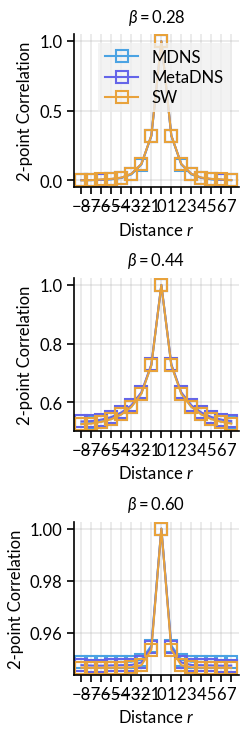

In [13]:
# ============================================================================
# Plot: Two-point Correlations
# ============================================================================
# Import the two-point correlation function
try:
    from utils_ising import ising_2pt_corr_direction
except ImportError:
    # Try alternative import path
    try:
        import sys
        sys.path.append(os.path.join(os.path.expanduser("~"), "MDNS"))
        from utils_ising import ising_2pt_corr_direction
    except ImportError:
        raise ImportError(
            "Could not import ising_2pt_corr_direction from utils_ising")

L = int(np.sqrt(NUM_SITES))
r_range = list(range(-L//2, L//2))  # [-4, -3, -2, -1, 0, 1, 2, 3, 4]
mc_block_idx = -1  # Which block to use for MCMC


def systematic_resample(weights, n_samples=None):
    """
    Systematic resampling for Sequential Monte Carlo.

    Parameters:
    -----------
    weights : np.ndarray
        Normalized importance weights, shape (n_samples,)
    n_samples : int, optional
        Number of samples to resample. If None, uses len(weights)

    Returns:
    --------
    np.ndarray
        Indices of resampled particles, shape (n_samples,)
    """
    weights = np.asarray(weights, dtype=np.float64)
    if n_samples is None:
        n_samples = len(weights)

    # Ensure weights are normalized
    weights = weights / weights.sum()

    # Systematic resampling
    u = np.random.uniform(0, 1.0 / n_samples)
    cumulative_weights = np.cumsum(weights)
    indices = np.zeros(n_samples, dtype=np.int64)

    j = 0
    for i in range(n_samples):
        u_i = u + i / n_samples
        while u_i > cumulative_weights[j]:
            j += 1
        indices[i] = j

    return indices


# Compute two-point correlations for each temperature and method
fig, ax = plt.subplots(
    len(all_temps), len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained"
)
# fig.suptitle(f"{MODEL_SIZE} Ising Two-point Correlations",
#              fontsize=12, weight="bold")

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"
        metadns_key = f"{temp:.4f}K_h{chem_pot:.4f}"

        # Labels only in first panel
        is_first_panel = (i == 0 and j == 0)
        labels = ("MDNS", "MetaDNS", "MCMC", "SW") if is_first_panel else (
            None, None, None, None)

        # Compute correlations for each method (average of horizontal and vertical)
        if mdns_key in mdns_configs:
            # MDNS: convert from [0,1] to [-1,1] format
            mdns_samples = torch.tensor(
                mdns_configs[mdns_key] * 2 - 1, dtype=torch.float32)
            mdns_corr = []
            for r in r_range:
                # Horizontal correlation (r_x=r, r_y=0)
                corr_x = ising_2pt_corr_direction(
                    mdns_samples, r_x=r, r_y=0, use_x=True, use_y=False)
                # Vertical correlation (r_x=0, r_y=r)
                corr_y = ising_2pt_corr_direction(
                    mdns_samples, r_x=0, r_y=r, use_x=False, use_y=True)
                # Convert to numpy if needed
                if isinstance(corr_x, torch.Tensor):
                    corr_x = corr_x.cpu().numpy()
                if isinstance(corr_y, torch.Tensor):
                    corr_y = corr_y.cpu().numpy()
                # Average horizontal and vertical correlations
                mdns_corr.append((corr_x + corr_y) / 2.0)
            mdns_corr = np.array(mdns_corr)
            ax[i, j].plot(r_range, mdns_corr,
                          markerfacecolor='none',
                          markeredgecolor=color_dict["MDNS"],
                          markeredgewidth=1.0,
                          linewidth=1.0,
                          color=color_dict.get("MDNS", "C1"),
                          marker=marker_dict.get("MDNS", "s"),
                          label=labels[0])

        if mdns_key in metadns_configs:
            # MetaDNS: convert from [0,1] to [-1,1] format and apply SMC-style resampling
            metadns_samples_raw = metadns_configs[mdns_key]
            metadns_samples = torch.tensor(
                metadns_samples_raw * 2 - 1, dtype=torch.float32)

            # Get log weights and compute importance weights using log-sum-exp trick
            # log_rw should be log(p(x)/q(x)) where p is target, q is biased distribution
            log_weights = metadns_log_rw[mdns_key]
            if isinstance(log_weights, torch.Tensor):
                log_weights = log_weights.cpu().numpy()
            log_weights = np.asarray(log_weights, dtype=np.float64)
            # Use log-sum-exp trick for numerical stability
            max_log_weight = np.max(log_weights)
            weights = np.exp(log_weights - max_log_weight)
            total_weight = np.sum(weights)
            weights = weights / total_weight  # Normalize weights

            # Diagnostic: compute effective sample size
            # ESS = (Σ w_i)^2 / Σ w_i^2, measures how many effective samples we have
            ess = (np.sum(weights))**2 / np.sum(weights **
                                                2) if np.sum(weights**2) > 0 else 0
            # If ESS is very low, importance sampling may be unreliable
            if is_first_panel and j == 0:  # Print once for first panel
                print(f"MetaDNS {mdns_key}: ESS = {ess:.1f} / {len(weights)} samples, "
                      f"weight range: [{np.min(weights):.2e}, {np.max(weights):.2e}]")

            # Resample samples according to importance weights (SMC-style)
            # This creates a new set of samples distributed according to the target distribution
            resampled_indices = systematic_resample(
                weights, n_samples=len(weights))
            metadns_samples_resampled = metadns_samples[resampled_indices]

            # Now compute correlations on resampled samples using standard function
            metadns_corr = []
            for r in r_range:
                # Horizontal correlation (r_x=r, r_y=0)
                corr_x = ising_2pt_corr_direction(
                    metadns_samples_resampled, r_x=r, r_y=0, use_x=True, use_y=False)
                # Vertical correlation (r_x=0, r_y=r)
                corr_y = ising_2pt_corr_direction(
                    metadns_samples_resampled, r_x=0, r_y=r, use_x=False, use_y=True)
                # Convert to numpy if needed
                if isinstance(corr_x, torch.Tensor):
                    corr_x = corr_x.cpu().numpy()
                if isinstance(corr_y, torch.Tensor):
                    corr_y = corr_y.cpu().numpy()
                # Average horizontal and vertical correlations
                metadns_corr.append((corr_x + corr_y) / 2.0)
            metadns_corr = np.array(metadns_corr)
            ax[i, j].plot(r_range, metadns_corr,
                          markerfacecolor='none',
                          markeredgecolor=color_dict["MetaDNS"],
                          markeredgewidth=1.0,
                          linewidth=1.0,
                          color=color_dict.get("MetaDNS", "C0"),
                          marker=marker_dict.get("MetaDNS", "s"),
                          label=labels[1])

        # MCMC: check if samples are in [0,1] or [-1,1] format
        # Assuming MCMC samples might already be in [-1,1] format, but let's check
        mcmc_samples_raw = mcmc_configs[key]["blocks"][mc_block_idx]
        # Try to detect format: if values are only 0 and 1, convert; otherwise assume already [-1,1]
        if np.all(np.isin(mcmc_samples_raw, [0, 1])):
            mcmc_samples = torch.tensor(
                mcmc_samples_raw * 2 - 1, dtype=torch.float32)
        else:
            mcmc_samples = torch.tensor(mcmc_samples_raw, dtype=torch.float32)

        mcmc_corr = []
        for r in r_range:
            # Horizontal correlation (r_x=r, r_y=0)
            corr_x = ising_2pt_corr_direction(
                mcmc_samples, r_x=r, r_y=0, use_x=True, use_y=False)
            # Vertical correlation (r_x=0, r_y=r)
            corr_y = ising_2pt_corr_direction(
                mcmc_samples, r_x=0, r_y=r, use_x=False, use_y=True)
            # Convert to numpy if needed
            if isinstance(corr_x, torch.Tensor):
                corr_x = corr_x.cpu().numpy()
            if isinstance(corr_y, torch.Tensor):
                corr_y = corr_y.cpu().numpy()
            # Average horizontal and vertical correlations
            mcmc_corr.append((corr_x + corr_y) / 2.0)
        mcmc_corr = np.array(mcmc_corr)
        # ax[i, j].plot(r_range, mcmc_corr,
        #               markerfacecolor='none',
        #               markeredgecolor=color_dict["MCMC"],
        #               markeredgewidth=1.0,
        #               linewidth=1.0,
        #               color=color_dict.get("MCMC", "C5"),
        #               marker=marker_dict.get("MCMC", "o"),
        #               label=labels[2])

        # SW: check if samples are in [0,1] or [-1,1] format
        sw_samples_raw = sw_configs[key]["blocks"][mc_block_idx]
        # Try to detect format: if values are only 0 and 1, convert; otherwise assume already [-1,1]
        if np.all(np.isin(sw_samples_raw, [0, 1])):
            sw_samples = torch.tensor(
                sw_samples_raw * 2 - 1, dtype=torch.float32)
        else:
            sw_samples = torch.tensor(sw_samples_raw, dtype=torch.float32)

        sw_corr = []
        for r in r_range:
            # Horizontal correlation (r_x=r, r_y=0)
            corr_x = ising_2pt_corr_direction(
                sw_samples, r_x=r, r_y=0, use_x=True, use_y=False)
            # Vertical correlation (r_x=0, r_y=r)
            corr_y = ising_2pt_corr_direction(
                sw_samples, r_x=0, r_y=r, use_x=False, use_y=True)
            # Average horizontal and vertical correlations
            sw_corr.append((corr_x + corr_y) / 2.0)
        sw_corr = np.array(sw_corr)
        ax[i, j].plot(r_range, sw_corr,
                      markerfacecolor='none',
                      markeredgecolor=color_dict["SW"],
                      markeredgewidth=1.0,
                      linewidth=1.0,
                      color=color_dict.get("SW", "C3"),
                      marker=marker_dict.get("SW", "s"),
                      label=labels[3])

        # Style subplot
        style_subplot_axes(
            ax[i, j],
            xlabel=r'Distance $r$',
            ylabel=r'2-point Correlation',
            title=format_subplot_title(temp, chem_pot)
        )
        ax[i, j].set_xticks(r_range)

create_legend(fig, ax)
fig.savefig(
    f'{output_dir}/{MODEL_SIZE}_ising_two_point_correlations.pdf', bbox_inches='tight')
fig.show()

  Using closest MetaDNS key: '1.6670K_h0.0000' for temp=1.6670
  Using closest MetaDNS key: '2.2690K_h0.0000' for temp=2.2690
  Using closest MetaDNS key: '3.5714K_h0.0000' for temp=3.5714


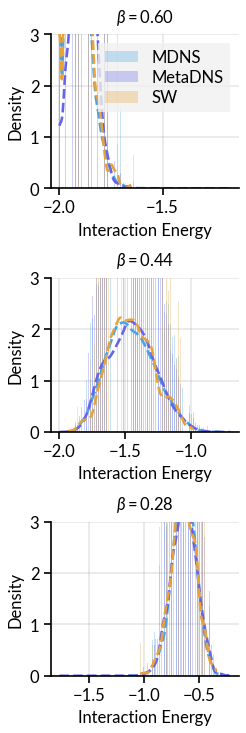

In [14]:
# ============================================================================
# Plotting Functions
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns


def _safe_hist(ax, data, *, weights=None, label=None, color="C0"):
    """Plot histogram with KDE, handling finite values safely.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on.
    data : array-like
        Data to histogram.
    weights : array-like, optional
        Weights for histogram.
    label : str, optional
        Label for legend.
    color : str, default="C0"
        Color for histogram.
    """
    values = np.asarray(data, dtype=float)
    mask = np.isfinite(values)
    finite_vals = values[mask]
    finite_weights = None
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        finite_weights = weights[mask]
        if finite_weights.sum() > 0:
            finite_weights = finite_weights / finite_weights.sum()
        else:
            finite_weights = None
    kde_ok = finite_vals.size > 1 and np.nanstd(finite_vals) > 1e-8
    sns.histplot(
        x=finite_vals,
        bins=NUM_SITES,
        stat="density",
        ax=ax,
        weights=finite_weights,
        label=label,
        kde=kde_ok,
        lw=0,
        color=color,
        alpha=HIST_ALPHA,
        line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH} if kde_ok else None,
    )


# ============================================================================
# Plot: Interaction Energy Distributions
# ============================================================================
mc_block_idx = -1  # Which block to use for MCMC
sample_size = 10000

fig, ax = plt.subplots(
    len(all_temps), len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained"
)
# fig.suptitle(f"{MODEL_SIZE} Ising Interaction Energy Distributions",
#              fontsize=12, weight="bold")

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(all_temps):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"

        # Try exact match first
        temp_key_str_base = f"{temp_val:.4f}K_h0.0000"
        mcmc_key_str = f"{temp_val:.1f}K_mu0.00"
        sw_key_str = f"{temp_val:.1f}K_mu0.00"  # SW uses same format as MCMC

        metadns_key = find_closest_key(
            temp, list(metadns_configs.keys()), "metadns")
        if metadns_key:
            print(
                f"  Using closest MetaDNS key: '{metadns_key}' for temp={temp:.4f}")
        else:
            metadns_key = None

        energy_scale = 1 / NUM_SITES

        # Sample data and plot histograms
        base_labels = ("MDNS", "MetaDNS", "MCMC", "SW") if (
            i == 0 and j == 0) else (None, None, None, None)

        if mdns_key in mdns_configs:
            # mdns
            mdns_sampled_idx = np.random.randint(
                0, len(mdns_configs[mdns_key]), sample_size)
            mdns_vals = mdns_energies[mdns_key][mdns_sampled_idx] * \
                energy_scale
            color = color_dict.get("MDNS", "C0")
            _safe_hist(ax[i, j], mdns_vals, label=base_labels[0],
                       color=color)

        # metadns WDCE
        if metadns_key in metadns_energies:
            metadns_sampled_idx = np.random.randint(
                0, len(metadns_configs[metadns_key]), sample_size)
            metadns_vals = metadns_energies[metadns_key][metadns_sampled_idx] * energy_scale
            color = color_dict.get("MetaDNS WDCE", "C0")
            _safe_hist(ax[i, j], metadns_vals, label=base_labels[1],
                       weights=metadns_weights[metadns_key][metadns_sampled_idx],
                       color=color)

        # MCMC reference
        # mcmc_sampled_idx = np.random.randint(
        #     0, len(mcmc_configs[key]["blocks"][mc_block_idx]), sample_size)
        # mcmc_vals = mcmc_energies[key]["blocks"][mc_block_idx][mcmc_sampled_idx] * energy_scale

        # _safe_hist(ax[i, j], mcmc_vals, label=base_labels[2],
        #            color=color_dict["MCMC"])

        # SW reference
        sw_sampled_idx = np.random.randint(
            0, len(sw_configs[key]["blocks"][mc_block_idx]), sample_size)
        sw_vals = sw_energies[key]["blocks"][mc_block_idx][sw_sampled_idx] * energy_scale
        _safe_hist(ax[i, j], sw_vals, label=base_labels[3],
                   color=color_dict["SW"])

        # Style subplot
        style_subplot_axes(
            ax[i, j],
            xlabel="Interaction Energy",
            title=format_subplot_title(temp, chem_pot)
        )
        ax[i, j].set_ylim(0, 3.0)

create_legend(fig, ax)
fig.savefig(
    f'{output_dir}/{MODEL_SIZE}_ising_interaction_energy_distributions.pdf', bbox_inches='tight')
fig.show()

In [15]:
metadns_key_str

'1.6667K_h0.0000'

  Using closest MetaDNS key: '1.6670K_h0.0000' for temp=1.6670
  Using closest MetaDNS key: '2.2690K_h0.0000' for temp=2.2690
  Using closest MetaDNS key: '3.5714K_h0.0000' for temp=3.5714


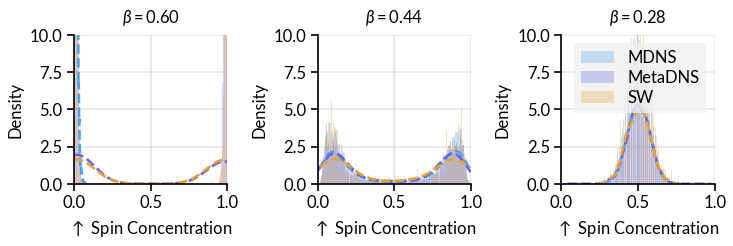

In [16]:
# ============================================================================
# Plot: Up-spin Concentration Distributions
# ============================================================================
fzig, ax = plt.subplots(
    len(all_chem_pots), len(all_temps),
    figsize=(FIG_WIDTH * len(all_temps), FIG_HEIGHT * len(all_chem_pots)),
    layout="constrained"
)
# fzig.suptitle(rf"{MODEL_SIZE} Ising Model $\uparrow$ Spin Concentration Distributions",
#               fontsize=12, weight="bold")

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_temps) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_chem_pots) == 1:
        ax = ax[np.newaxis, :]

for j, chem_pot in enumerate(all_chem_pots):
    for i, temp in enumerate(all_temps):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"

        # Try exact match first
        temp_key_str_base = f"{temp_val:.4f}K_h0.0000"
        mcmc_key_str = f"{temp_val:.1f}K_mu0.00"
        sw_key_str = f"{temp_val:.1f}K_mu0.00"  # SW uses same format as MCMC

        metadns_key = find_closest_key(
            temp, list(metadns_x_up.keys()), "metadns")
        if metadns_key:
            print(
                f"  Using closest MetaDNS key: '{metadns_key}' for temp={temp:.4f}")
        else:
            metadns_key = None

        energy_scale = 1 / NUM_SITES

        # Plot histograms (only label in top-left panel)
        is_first_panel = (j == 0 and i == 0)
        labels = ("MDNS", "MetaDNS", "MCMC", "SW") if is_first_panel else (
            None, None, None, None)

        if mdns_key in mdns_configs:
            # mdns
            color = color_dict.get("MDNS", "C0")
            sns.histplot(
                x=mdns_x_up[mdns_key], bins=NUM_SITES, stat="density", ax=ax[j, i],
                label=labels[0], kde=True, lw=0,
                color=color,
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
            )

        # metadns WDCE
        if metadns_key in metadns_x_up:
            color = color_dict.get("MetaDNS WDCE", "C0")
            sns.histplot(
                x=metadns_x_up[metadns_key], bins=NUM_SITES, stat="density", ax=ax[j, i],
                weights=metadns_weights[metadns_key],
                label=labels[1], kde=True, lw=0,
                color=color,
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
            )

        # MCMC reference
        # sns.histplot(
        #     x=mcmc_x_up[key]["blocks"][mc_block_idx], bins=NUM_SITES, stat="density", ax=ax[j, i],
        #     label=labels[2], kde=True, lw=0,
        #     color=color_dict["MCMC"],
        #     alpha=HIST_ALPHA,
        #     line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
        # )

        # SW reference
        sns.histplot(
            x=sw_x_up[key]["blocks"][mc_block_idx], bins=NUM_SITES, stat="density", ax=ax[j, i],
            label=labels[3], kde=True, lw=0,
            color=color_dict["SW"],
            alpha=HIST_ALPHA,
            line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
        )

        # Style subplot
        style_subplot_axes(
            ax[j, i],
            xlabel=r"$\uparrow$ Spin Concentration",
            title=format_subplot_title(temp, chem_pot)
        )
        ax[j, i].set_xlim(0, 1)
        ax[j, i].set_ylim(0, 10)

create_legend(fzig, ax)
fzig.savefig(
    f'{output_dir}/{MODEL_SIZE}_ising_up_spin_concentration_distributions.pdf', bbox_inches='tight')
fzig.show()

Plot JS divergence over block iterations

In [17]:
import numpy as np


def kl_divergence(p, q, *, base=None, normalize=True):
    """KL(p || q) for nonnegative vectors p, q."""
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    if p.shape != q.shape:
        raise ValueError("Distributions must have the same shape.")
    if np.any(p < 0) or np.any(q < 0):
        raise ValueError("Distributions must be nonnegative.")

    if normalize:
        p_sum = p.sum()
        q_sum = q.sum()
        if p_sum <= 0 or q_sum <= 0:
            raise ValueError(
                "Distributions must have strictly positive total mass.")
        p = p / p_sum
        q = q / q_sum

    mask = p > 0
    if np.any(q[mask] <= 0):
        raise ValueError("q must be positive wherever p is positive.")

    kl = np.sum(p[mask] * (np.log(p[mask]) - np.log(q[mask])))
    if base is not None:
        kl /= np.log(base)
    return kl


def _hist_to_mass(hist, bins, *, density):
    """Convert np.histogram output to bin probabilities (unnormalized mass)."""
    hist = np.asarray(hist, dtype=np.float64)
    bins = np.asarray(bins, dtype=np.float64)

    if bins.shape[0] != hist.shape[0] + 1:
        raise ValueError("Bin edges must have length len(hist) + 1.")

    if density:
        # hist is a density: p_i = f_i * width_i
        widths = np.diff(bins)
        mass = hist * widths
    else:
        # hist is counts: use directly as mass
        mass = hist.astype(np.float64)

    if np.any(mass < 0):
        raise ValueError("Histogram values must be nonnegative.")

    return mass


def kl_from_hist(
    hist_p, bins_p,
    hist_q, bins_q,
    *,
    base=None,
    density=True,
):
    """KL(P || Q) from np.histogram outputs."""
    hist_p = np.asarray(hist_p, dtype=np.float64)
    hist_q = np.asarray(hist_q, dtype=np.float64)
    bins_p = np.asarray(bins_p, dtype=np.float64)
    bins_q = np.asarray(bins_q, dtype=np.float64)

    if hist_p.shape != hist_q.shape:
        raise ValueError("Histograms must have the same number of bins.")
    if bins_p.shape != bins_q.shape:
        raise ValueError("Bin edge arrays must have the same shape.")
    if not np.allclose(bins_p, bins_q):
        raise ValueError("Bin edges must match for KL divergence.")

    p = _hist_to_mass(hist_p, bins_p, density=density)
    q = _hist_to_mass(hist_q, bins_q, density=density)

    return kl_divergence(p, q, base=base, normalize=True)


def js_from_hist(
    hist_p, bins_p,
    hist_q, bins_q,
    *,
    base=None,
    density=True,
):
    """Jensen–Shannon divergence between two histograms."""
    hist_p = np.asarray(hist_p, dtype=np.float64)
    hist_q = np.asarray(hist_q, dtype=np.float64)
    bins_p = np.asarray(bins_p, dtype=np.float64)
    bins_q = np.asarray(bins_q, dtype=np.float64)

    if hist_p.shape != hist_q.shape:
        raise ValueError("Histograms must have the same number of bins.")
    if bins_p.shape != bins_q.shape:
        raise ValueError("Bin edge arrays must have the same shape.")
    if not np.allclose(bins_p, bins_q):
        raise ValueError("Bin edges must match for JS divergence.")

    # Convert to (unnormalized) mass in each bin
    p = _hist_to_mass(hist_p, bins_p, density=density)
    q = _hist_to_mass(hist_q, bins_q, density=density)

    # Normalise once here
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)   # already normalised since sum(m) = 1

    # Use KL on already-normalised distributions
    return 0.5 * (
        kl_divergence(p, m, base=base, normalize=False)
        + kl_divergence(q, m, base=base, normalize=False)
    )

In [18]:
# Calculate JS divergence over block iterations for MCMC energy and x_up distributions
# At each temperature and chemical potential, calculate the JS divergence between the MCMC energy and x_up distributions
# and the ARM and MAM Transformer distributions
js_div_energy = defaultdict(list)
js_div_x_up = defaultdict(list)
step_size = 250
step_number_list = []

blocks_length = None  # to accumulate step_number only once

# Visualize MCMC energy and x_up distribution changes over block iterations
plot_every = 10
mc_energies_to_plot = defaultdict(list)
mc_x_up_to_plot = defaultdict(list)
mc_labels_to_plot = defaultdict(list)
mc_colors_to_plot = defaultdict(list)

for temp in all_temps:
    for chem_pot in all_chem_pots:
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"

        last_block_idx = len(mcmc_energies[key]["blocks"]) - 1
        last_mcmc_energy = mcmc_energies[key]["blocks"][last_block_idx]
        last_mcmc_x_up = mcmc_x_up[key]["blocks"][last_block_idx]

        min_energy, max_energy = last_mcmc_energy.min(), last_mcmc_energy.max()
        min_x_up, max_x_up = last_mcmc_x_up.min(), last_mcmc_x_up.max()

        # Create distributions for last block
        last_mcmc_energy_dist = np.histogram(
            last_mcmc_energy, bins=100, range=(min_energy, max_energy), density=True)
        last_mcmc_x_up_dist = np.histogram(
            last_mcmc_x_up, bins=100, range=(min_x_up, max_x_up), density=True)
        last_energy_bins = last_mcmc_energy_dist[1]
        last_x_up_bins = last_mcmc_x_up_dist[1]

        if blocks_length is None:
            blocks_length = len(mcmc_energies[key]["blocks"])
            # Only fill step_number_list once (assuming all keys have same length)!
            step_number_list.extend(
                [i * step_size for i in range(blocks_length)])

        for block_idx in range(len(mcmc_energies[key]["blocks"])):
            if block_idx % plot_every == 0:
                mc_energies_to_plot[key].append(
                    mcmc_energies[key]["blocks"][block_idx])
                mc_x_up_to_plot[key].append(
                    mcmc_x_up[key]["blocks"][block_idx])
                mc_labels_to_plot[key].append(f"MCMC {block_idx * step_size}")
                mc_colors_to_plot[key].append(color_dict["MCMC"])

            current_mcmc_energy = mcmc_energies[key]["blocks"][block_idx]
            current_mcmc_x_up = mcmc_x_up[key]["blocks"][block_idx]

            # Create distributions for current block using the same bin edges as the reference block
            current_mcmc_energy_dist = np.histogram(
                current_mcmc_energy, bins=last_energy_bins, density=True)
            current_mcmc_x_up_dist = np.histogram(
                current_mcmc_x_up, bins=last_x_up_bins, density=True)

            # Calculate JS divergence between current MCMC energy and last MCMC energy
            js_div_energy[key].append(js_from_hist(
                *current_mcmc_energy_dist, *last_mcmc_energy_dist))

            # Calculate JS divergence between current MCMC x_up and last MCMC x_up
            js_div_x_up[key].append(js_from_hist(
                *current_mcmc_x_up_dist, *last_mcmc_x_up_dist))

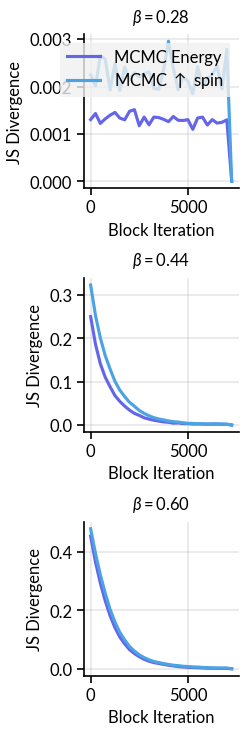

In [19]:
# ============================================================================
# Plot: JS Divergence over Block Iterations
# ============================================================================
js_color_dict = {"MCMC Energy": "C0", "MCMC x_up": "C1"}

fig, ax = plt.subplots(
    len(all_temps), len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained"
)

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        is_first_panel = (i == 0 and j == 0)
        labels = ("MCMC Energy", r"MCMC $\uparrow$ spin") if is_first_panel else (
            None, None)

        ax[i, j].plot(step_number_list, js_div_energy[key],
                      label=labels[0], color=js_color_dict["MCMC Energy"])
        ax[i, j].plot(step_number_list, js_div_x_up[key],
                      label=labels[1], color=js_color_dict["MCMC x_up"])

        style_subplot_axes(
            ax[i, j],
            xlabel="Block Iteration",
            ylabel="JS Divergence",
            title=format_subplot_title(temp, chem_pot)
        )

create_legend(fig, ax)
plt.show()
plt.close(fig)

In [20]:
# Helper function to calculate JS divergence from raw data arrays
def js_from_data(
    data_p,
    data_q,
    *,
    bins=None,
    range=None,
    weights_p=None,
    weights_q=None,
    base=None,
    density=True,
):
    """Calculate JS divergence from raw data arrays.

    Parameters
    ----------
    data_p : array-like
        First dataset (e.g., MDNS or MetaDNS)
    data_q : array-like
        Second dataset (e.g., MCMC)
    bins : int or array-like, optional
        Number of bins or bin edges. If None, uses NUM_SITES.
    range : tuple, optional
        Range for histogram bins (min, max). If None, uses data range.
    weights_p : array-like, optional
        Weights for data_p (e.g., for MetaDNS)
    weights_q : array-like, optional
        Weights for data_q
    base : float, optional
        Logarithm base for JS divergence (e.g., 2 for bits)
    density : bool, default=True
        If True, normalize histogram to density

    Returns
    -------
    float
        JS divergence between the two distributions
    """
    data_p = np.asarray(data_p, dtype=np.float64)
    data_q = np.asarray(data_q, dtype=np.float64)

    # Filter finite values
    mask_p = np.isfinite(data_p)
    mask_q = np.isfinite(data_q)

    finite_p = data_p[mask_p]
    finite_q = data_q[mask_q]

    # Handle weights
    finite_weights_p = None
    if weights_p is not None:
        weights_p = np.asarray(weights_p, dtype=np.float64)
        finite_weights_p = weights_p[mask_p]
        if finite_weights_p.sum() > 0:
            finite_weights_p = finite_weights_p / finite_weights_p.sum()
        else:
            finite_weights_p = None

    finite_weights_q = None
    if weights_q is not None:
        weights_q = np.asarray(weights_q, dtype=np.float64)
        finite_weights_q = weights_q[mask_q]
        if finite_weights_q.sum() > 0:
            finite_weights_q = finite_weights_q / finite_weights_q.sum()
        else:
            finite_weights_q = None

    # Determine bins and range
    if range is None:
        data_min = min(finite_p.min(), finite_q.min())
        data_max = max(finite_p.max(), finite_q.max())
        range = (data_min, data_max)

    if bins is None:
        bins = NUM_SITES

    # Create histograms with same bins
    hist_p, bins_p = np.histogram(
        finite_p, bins=bins, range=range, weights=finite_weights_p, density=density
    )
    hist_q, bins_q = np.histogram(
        finite_q, bins=bins, range=range, weights=finite_weights_q, density=density
    )

    # Calculate JS divergence
    return js_from_hist(hist_p, bins_p, hist_q, bins_q, base=base, density=density)

In [21]:
# Calculate JS divergence for MDNS and MetaDNS vs MCMC
# For interaction energies and x_up
mc_block_idx = -1  # Which MCMC block to use for comparison
energy_scale = 1 / NUM_SITES

# Storage for results
js_div_results = {
    "MDNS_energy": {},
    "MetaDNS_energy": {},
    "MDNS_x_up": {},
    "MetaDNS_x_up": {},
}

for temp in all_temps:
    # Find matching keys for each method
    mdns_key = find_closest_key(temp, list(mdns_x_up.keys()), "mdns")
    metadns_key = find_closest_key(temp, list(metadns_x_up.keys()), "metadns")
    mcmc_key = find_closest_key(temp, list(mcmc_x_up.keys()), "mcmc")

    # Skip if MCMC data doesn't exist
    if not mcmc_key:
        continue

    # Get MCMC data (use last block)
    if mcmc_key in mcmc_energies and len(mcmc_energies[mcmc_key]["blocks"]) > 0:
        mcmc_corr_y_energy = mcmc_energies[mcmc_key]["blocks"][mc_block_idx] * energy_scale
    else:
        mcmc_energy = None

    if mcmc_key in mcmc_x_up and len(mcmc_x_up[mcmc_key]["blocks"]) > 0:
        mcmc_x_up_data = mcmc_x_up[mcmc_key]["blocks"][mc_block_idx]
    else:
        mcmc_x_up_data = None

    # Get SW data
    sw_key = find_closest_key(temp, list(sw_x_up.keys()), "sw")
    if sw_key in sw_energies and len(sw_energies[sw_key]["blocks"]) > 0:
        sw_energy = sw_energies[sw_key]["blocks"][mc_block_idx] * energy_scale
    else:
        sw_energy = None

    if sw_key in sw_x_up and len(sw_x_up[sw_key]["blocks"]) > 0:
        sw_x_up_data = sw_x_up[sw_key]["blocks"][mc_block_idx]
    else:
        sw_x_up_data = None

    # Comparison either with MCMC or with SW
    comparison_energy = sw_energy
    comparison_x_up_data = sw_x_up_data
    comparison_str = "SW"

    # Calculate JS divergence for interaction energies
    if mdns_key and comparison_energy is not None and mdns_key in mdns_energies:
        # MDNS vs MCMC (energy)
        js_div_results["MDNS_energy"][mdns_key] = js_from_data(
            mdns_energies[mdns_key] * energy_scale,
            comparison_energy,
            bins=NUM_SITES,
            density=True,
        )

    if mdns_key and comparison_x_up_data is not None:
        # MDNS vs MCMC (x_up)
        js_div_results["MDNS_x_up"][mdns_key] = js_from_data(
            mdns_x_up[mdns_key],
            comparison_x_up_data,
            bins=NUM_SITES,
            density=True,
        )

    if metadns_key and comparison_energy is not None and metadns_key in metadns_energies:
        # MetaDNS vs MCMC (energy) - with weights
        weights_p = metadns_weights.get(metadns_key, None)
        js_div_results["MetaDNS_energy"][metadns_key] = js_from_data(
            metadns_energies[metadns_key] * energy_scale,
            comparison_energy,
            weights_p=weights_p,
            bins=NUM_SITES,
            density=True,
        )

    if metadns_key and comparison_x_up_data is not None:
        # MetaDNS vs MCMC (x_up) - with weights
        weights_p = metadns_weights.get(metadns_key, None)
        js_div_results["MetaDNS_x_up"][metadns_key] = js_from_data(
            metadns_x_up[metadns_key],
            comparison_x_up_data,
            weights_p=weights_p,
            bins=NUM_SITES,
            density=True,
        )

# Print results
print(f"JS Divergence Results (MDNS/MetaDNS vs {comparison_str})")
print("=" * 60)
print(f"\nUsing {comparison_str} block index: {mc_block_idx}")
print(f"Energy scale factor: {energy_scale:.4f}")
print("\n" + "-" * 60)

for temp in all_temps:
    mdns_key = find_closest_key(temp, list(mdns_x_up.keys()), "mdns")
    metadns_key = find_closest_key(temp, list(metadns_x_up.keys()), "metadns")

    print(f"\nTemperature: {temp:.4f} K")
    if mdns_key:
        print(f"  Key: {mdns_key}")

    if mdns_key and mdns_key in js_div_results["MDNS_energy"]:
        print(
            f"  MDNS Energy JS Div:     {js_div_results['MDNS_energy'][mdns_key]:.6f}")
    if mdns_key and mdns_key in js_div_results["MDNS_x_up"]:
        print(
            f"  MDNS x_up JS Div:       {js_div_results['MDNS_x_up'][mdns_key]:.6f}")

    if metadns_key and metadns_key in js_div_results["MetaDNS_energy"]:
        print(
            f"  MetaDNS Energy JS Div:  {js_div_results['MetaDNS_energy'][metadns_key]:.6f}")
    if metadns_key and metadns_key in js_div_results["MetaDNS_x_up"]:
        print(
            f"  MetaDNS x_up JS Div:     {js_div_results['MetaDNS_x_up'][metadns_key]:.6f}")

print("\n" + "=" * 60)

JS Divergence Results (MDNS/MetaDNS vs SW)

Using SW block index: -1
Energy scale factor: 0.0039

------------------------------------------------------------

Temperature: 1.6670 K
  Key: 1.6670K_h0.0000
  MDNS Energy JS Div:     0.004349
  MDNS x_up JS Div:       0.217667
  MetaDNS Energy JS Div:  0.033227
  MetaDNS x_up JS Div:     0.046242

Temperature: 2.2690 K
  Key: 2.2690K_h0.0000
  MDNS Energy JS Div:     0.011217
  MDNS x_up JS Div:       0.036072
  MetaDNS Energy JS Div:  0.013881
  MetaDNS x_up JS Div:     0.042007

Temperature: 3.5714 K
  Key: 3.5714K_h0.0000
  MDNS Energy JS Div:     0.006210
  MDNS x_up JS Div:       0.017446
  MetaDNS Energy JS Div:  0.006854
  MetaDNS x_up JS Div:     0.016657



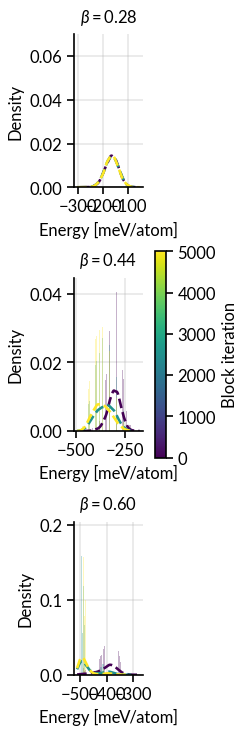

In [22]:
# ============================================================================
# Plot: MCMC Energy Distribution Evolution over Block Iterations
# ============================================================================
# from snowyflow.tools.ising_eval import get_periodic_table_colormap

# cmap = get_periodic_table_colormap()
cmap = plt.cm.viridis

# Extract all block step numbers for normalization
all_plot_steps = []
for labels in mc_labels_to_plot.values():
    for label in labels:
        try:
            all_plot_steps.append(int(label.split()[-1]))
        except (ValueError, IndexError):
            all_plot_steps.append(0)

norm = plt.Normalize(vmin=min(all_plot_steps), vmax=max(
    all_plot_steps)) if all_plot_steps else plt.Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(
    len(all_temps), len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained"
)

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        labels = mc_labels_to_plot[key]
        energies = mc_energies_to_plot[key]

        # Extract block steps for this panel
        block_steps = []
        for label in labels:
            try:
                block_steps.append(int(label.split()[-1]))
            except (ValueError, IndexError):
                block_steps.append(0)

        # Plot histograms for each block iteration
        is_first_panel = (i == 0 and j == 0)
        for k, label in enumerate(labels):
            energy_vals = energies[k]
            color = cmap(norm(block_steps[k])) if block_steps else cmap(0.5)
            _safe_hist(
                ax[i, j],
                energy_vals,
                label=label if is_first_panel else None,
                color=color,
            )

        style_subplot_axes(
            ax[i, j],
            xlabel="Energy [meV/atom]",
            ylabel="Density",
            title=format_subplot_title(temp, chem_pot)
        )

# Add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax.ravel().tolist(), shrink=0.8, label="Block iteration")

fig.show()
# plt.close(fig)

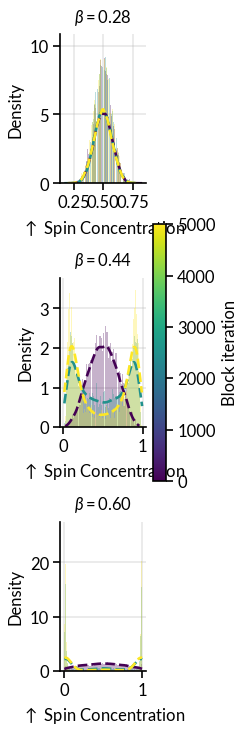

In [23]:
# ============================================================================
# Plot: MCMC Up-spin Concentration Distribution Evolution over Block Iterations
# ============================================================================
fig, ax = plt.subplots(
    len(all_temps), len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained"
)

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        labels = mc_labels_to_plot[key]
        x_ups = mc_x_up_to_plot[key]

        # Extract block steps for this panel
        block_steps = []
        for label in labels:
            try:
                block_steps.append(int(label.split()[-1]))
            except (ValueError, IndexError):
                block_steps.append(0)

        # Plot histograms for each block iteration
        is_first_panel = (i == 0 and j == 0)
        for k, label in enumerate(labels):
            x_up_vals = x_ups[k]
            color = cmap(norm(block_steps[k])) if block_steps else cmap(0.5)
            _safe_hist(
                ax[i, j],
                x_up_vals,
                label=label if is_first_panel else None,
                color=color,
            )

        style_subplot_axes(
            ax[i, j],
            xlabel=r"$\uparrow$ Spin Concentration",
            ylabel="Density",
            title=format_subplot_title(temp, chem_pot)
        )

# Add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax.ravel().tolist(), shrink=0.8, label="Block iteration")

fig.show()
# plt.close(fig)